### Antecedentes
El problema prototípico de transporte trata sobre la distribución de un producto desde un conjunto de orígenes (fuentes) a un conjunto de destinos. El objetivo es minimizar los costos totales de transporte mientras se satisfacen las restricciones sobre los suministros disponibles en cada uno de los orígenes y se cumplen los requisitos de demanda en cada uno de los destinos.

Aquí ilustramos el problema de transporte usando un ejemplo del Capítulo 5 de Johannes Bisschop, “AIMMS Optimization Modeling”, Paragon Decision Sciences, 1999. En este ejemplo hay dos fábricas y seis sitios de clientes ubicados en 8 ciudades europeas, como se muestra en el siguiente mapa. Los sitios de clientes están etiquetados en rojo, las fábricas están etiquetadas en azul.

Los costos de transporte entre orígenes y destinos se dan en unidades de €/tonelada de mercancía enviada, y se enumeran en la siguiente tabla junto con la capacidad de origen y los requisitos de demanda.


| Cliente/Origen | Arnhem [€/ton] | Gouda [€/ton] | Demanda [toneladas] |
|----------------|----------------|---------------|--------------------|
| Londres        | -              | 2.5           | 125                |
| Berlín         | 2.5            | -             | 175                |
| Maastricht     | 1.6            | 2.0           | 225                |
| Ámsterdam      | 1.4            | 1.0           | 250                |
| Utrecht        | 0.8            | 1.0           | 225                |
| La Haya        | 1.4            | 0.8           | 200                |
| **Suministro [toneladas]** | 550            | 700           |                    |

%%markdown
## Formulación Matemática

El problema es un modelo de **Programación Lineal (PL)**.

**Conjuntos:**
* $Sources$: Conjunto de  (Fábricas: $\text{Arnhem, Gouda}$).
* $Customers$: Conjunto de Destinos (Clientes: $\text{Londres, Berlín, ...}$).

### 1. Función Objetivo (Minimizar Costo Total)

$$\min \quad Z = \sum_{c \in Customers} \sum_{s \in Sources} T_{c,s} \cdot x_{c,s}$$

### 2. Restricciones

#### A. Restricción de Suministro (Capacidad del Origen)

Los envíos totales que salen de cada origen $i$ no pueden exceder su capacidad de suministro $S_i$:

$$\sum_{c \in Customers} x_{c,s} \le Supply_{s} \quad \forall s \in Sources$$

#### B. Restricción de Demanda (Requisito del Cliente)

Los envíos totales que llegan a cada destino $j$ deben satisfacer su demanda $D_j$:

$$\sum_{s \in Sources} x_{c,s} = D_c \quad \forall c \in Customers$$

#### C. Restricción de No Negatividad

La cantidad enviada debe ser no negativa:

$$x_{c,s} \ge 0 \quad \forall i \in I, j \in J$$


### Cargar los datos

In [7]:
Demand = {
   'Lon': 125,        # London
   'Ber': 175,        # Berlin
   'Maa': 225,        # Maastricht
   'Ams': 250,        # Amsterdam
   'Utr': 225,        # Utrecht
   'Hag': 200         # The Hague
}

Supply = {
   'Arn': 600,        # Arnhem
   'Gou': 650         # Gouda
}

T = {
    ('Lon', 'Arn'): 1000,
    ('Lon', 'Gou'): 2.5,
    ('Ber', 'Arn'): 2.5,
    ('Ber', 'Gou'): 1000,
    ('Maa', 'Arn'): 1.6,
    ('Maa', 'Gou'): 2.0,
    ('Ams', 'Arn'): 1.4,
    ('Ams', 'Gou'): 1.0,
    ('Utr', 'Arn'): 0.8,
    ('Utr', 'Gou'): 1.0,
    ('Hag', 'Arn'): 1.4,
    ('Hag', 'Gou'): 0.8
}

### Cargamos las librerías

In [8]:
import pyomo.environ as pe
import pyomo.opt as po
import pandas as pd

### Implementar el modelo

In [9]:
model= pe.ConcreteModel()

In [10]:
# Conjuntos
model.Origins   = pe.Set(initialize=Supply.keys())
model.Customers = pe.Set(initialize=Demand.keys())
model.Paths     = pe.Set(initialize=T.keys(), dimen=2)

# Parámetros
model.supply = pe.Param(model.Origins,   initialize=Supply, within=pe.NonNegativeReals)
model.demand = pe.Param(model.Customers, initialize=Demand, within=pe.NonNegativeReals)
model.cost   = pe.Param(model.Paths,     initialize=T)


model.Origins es el conjunto de orígenes ({'Arn', 'Gou'}).

initialize=Supply le dice: "usa el diccionario Supply para llenar los valores".

In [11]:
model.x= pe.Var(model.Paths, domain=pe.PositiveReals)

In [12]:
#Definimos nuestras constricciones
def cons(model, s):
    return sum(model.x[c,s] for c in model.Customers if (c,s) in model.Paths) <= model.supply[s]

model.constricion = pe.Constraint(model.Origins, rule=cons)

#Para cada origen s, suma de lo enviado desde s a todos los clientes ≤ oferta de s.
#El if (c,s) in model.Paths evita errores cuando no existe la ruta.

In [16]:
def cons1(model, c):
    return sum(model.x[c,s] for s in model.Origins if (c,s) in model.Paths) == model.demand[c]
model.cons1 = pe.Constraint(model.Customers, rule=cons1)

'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.constraint.IndexedConstraint'>). This
is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().


In [17]:
### Función objetivo
def obj(model):
    return sum(model.cost[c,s] * model.x[c,s] for (c,s) in model.Paths)
model.obj = pe.Objective(rule=obj, sense=pe.minimize)

### Resolver

In [18]:
solver = po.SolverFactory('glpk')
results = solver.solve(model, tee=True)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp_iz8czh6.glpk.raw
 --wglp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp9045ixgx.glpk.glp
 --cpxlp /var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpn2jcxsxc.pyomo.lp
Reading problem data from '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmpn2jcxsxc.pyomo.lp'...
8 rows, 12 columns, 24 non-zeros
81 lines were read
Writing problem data to '/var/folders/hb/c3zh8bns0mx4nw98_6k7rx8m0000gn/T/tmp9045ixgx.glpk.glp'...
67 lines were written
GLPK Simplex Optimizer 5.0
8 rows, 12 columns, 24 non-zeros
Preprocessing...
8 rows, 12 columns, 24 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 8
      0: obj =   1.763975000e+05 inf =   5.500e+02 (1)
      4: obj =   1.264425000e+05 inf =   0.000e+00 (0)
*     7: obj =   1.7

In [19]:
model.obj.display()

obj : Size=1, Index=None, Active=True
    Key  : Active : Value
    None :   True : 1705.0


In [20]:
model.x.display()

x : Size=12, Index=Paths
    Key            : Lower : Value : Upper : Fixed : Stale : Domain
    ('Ams', 'Arn') :     0 :   0.0 :  None : False : False : PositiveReals
    ('Ams', 'Gou') :     0 : 250.0 :  None : False : False : PositiveReals
    ('Ber', 'Arn') :     0 : 175.0 :  None : False : False : PositiveReals
    ('Ber', 'Gou') :     0 :   0.0 :  None : False : False : PositiveReals
    ('Hag', 'Arn') :     0 :   0.0 :  None : False : False : PositiveReals
    ('Hag', 'Gou') :     0 : 200.0 :  None : False : False : PositiveReals
    ('Lon', 'Arn') :     0 :   0.0 :  None : False : False : PositiveReals
    ('Lon', 'Gou') :     0 : 125.0 :  None : False : False : PositiveReals
    ('Maa', 'Arn') :     0 : 225.0 :  None : False : False : PositiveReals
    ('Maa', 'Gou') :     0 :   0.0 :  None : False : False : PositiveReals
    ('Utr', 'Arn') :     0 : 200.0 :  None : False : False : PositiveReals
    ('Utr', 'Gou') :     0 :  25.0 :  None : False : False : PositiveReals


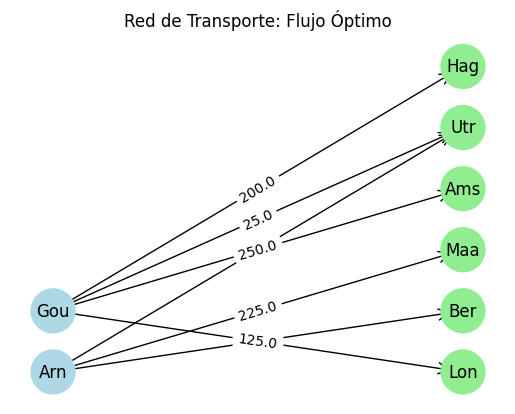

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear un grafo dirigido
G = nx.DiGraph()

# Agregar nodos de orígenes y clientes
for o in model.Origins:
    G.add_node(o, color='lightblue', tipo='Origen')

for c in model.Customers:
    G.add_node(c, color='lightgreen', tipo='Cliente')

# Agregar arcos con los valores óptimos
for (c, o) in model.Paths:
    val = pe.value(model.x[c, o])
    if val > 0:  # solo mostramos las rutas que se usan
        G.add_edge(o, c, weight=model.cost[c, o], flow=val)

# Posiciones para graficar (puedes cambiarlas para que quede más claro)
pos = {}
# Orígenes a la izquierda
for i, o in enumerate(model.Origins):
    pos[o] = (-1, i)
# Clientes a la derecha
for j, c in enumerate(model.Customers):
    pos[c] = (1, j)

# Dibujar nodos
colors = [G.nodes[n]['color'] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1000)

# Dibujar etiquetas
nx.draw_networkx_labels(G, pos)

# Dibujar arcos
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)

# Dibujar etiquetas de flujo (solución)
edge_labels = {(u, v): f"{d['flow']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Red de Transporte: Flujo Óptimo")
plt.axis('off')
plt.show()
